# Fase 6 — Polarization Measurement
> Dependensi: Fase 3 (`score_positif/negatif`) + Fase 5 (`community`, `betweenness`)

**Tujuan:**
1. Controversy score per tweet
2. Frame-level polarization index
3. Network-based polarization (cross-community isolation)
4. Temporal polarization trends
5. Korelasi polarization × topic × sentiment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import sys
sys.path.append('../Src')
from Src.config import ANALYZED_DATA, FIG_DIR

fig_pol_dir = str(FIG_DIR / 'polarization')
os.makedirs(fig_pol_dir, exist_ok=True)

df = pd.read_csv(ANALYZED_DATA)
print(f"Shape: {df.shape}")

# Cek kolom yang dibutuhkan
required = ['score_positif', 'score_negatif', 'score_netral', 'sentiment_bert',
            'community', 'betweenness', 'view_count']
for c in required:
    status = '✅' if c in df.columns else '❌ MISSING'
    print(f"  {status} {c}")

# Parse numerics
for c in ['score_positif', 'score_negatif', 'score_netral', 'view_count']:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)

if 'created_at' in df.columns:
    df['created_at_dt'] = pd.to_datetime(df['created_at'], errors='coerce')

Shape: (15000, 57)
  ✅ score_positif
  ✅ score_negatif
  ✅ score_netral
  ✅ sentiment_bert
  ✅ community
  ✅ betweenness
  ✅ view_count


/var/folders/2k/9v42dhzd2rdg1nkfsqt49skw0000gn/T/ipykernel_3195/2540040060.py:30: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['created_at_dt'] = pd.to_datetime(df['created_at'], errors='coerce')


In [2]:
# Load network graph dari Fase 5
graph_path = '../Data/Cache/network_graph.pkl'
if os.path.exists(graph_path):
    with open(graph_path, 'rb') as f:
        net_data = pickle.load(f)
    G_combined = net_data['G_combined']
    partition = net_data['partition']
    print(f"Graph loaded: {G_combined.number_of_nodes()} nodes, {G_combined.number_of_edges()} edges")
    print(f"Communities: {len(set(partition.values()))}")
else:
    print("⚠️ network_graph.pkl not found. Run Fase 5 first.")
    G_combined = None
    partition = None

Graph loaded: 11872 nodes, 13995 edges
Communities: 1518


## P6-01: Controversy Score per Tweet

=== DISTRIBUSI CONTROVERSY SCORE ===
count    15000.000000
mean         0.389460
std          0.454510
min          0.000146
25%          0.000712
50%          0.037932
75%          0.994587
max          1.000000
Name: controversy_score, dtype: float64


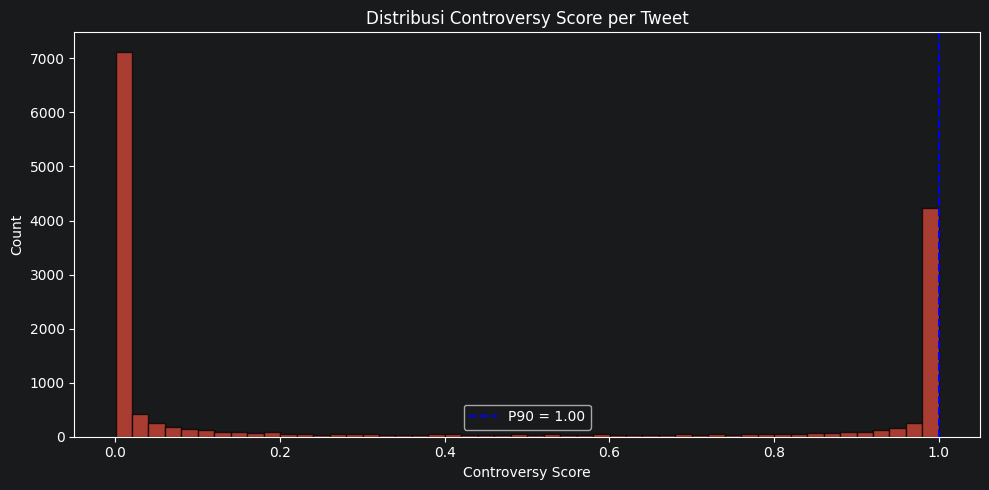


Top 10 tweet paling kontroversial:
  [1.000] Pemkab Lampung Selatan Siapkan Lahan untuk Dapur Program Makan Bergizi Gratis (MBG) https://t.co/ErwUKXsE2Y
  [1.000] Salah satu sumber cuwan yg lain.. MBG, food estate, alutsista, hilirisasi isih kurang?
  [1.000] @BigAlphaID MBG dari awal keluar ga pernah ada itungan detailnya 😂
  [1.000] Juru Bicara Kepresidenan menegaskan program Makan Bergizi Gratis (MBG) memberikan gizi setara untuk siswa SLB dan regule
  [1.000] BGN Jalin Kerja Sama dengan Unhan Didik Ribuan SDM Demi Kesuksesan MBG BGN Jalin Kerja Sama dengan Unhan Didik Ribuan SD
  [1.000] MBG adekku kacang sukro 3 bungkus sm jeruk, roti 2ribuan dan susu 😂🤣
  [1.000] Barusan lihat liputan6 berita "ditemukan ulat di MBG 😨" di daerah Kalsel
  [1.000] Pffttt mbg ini kmrn dibahas di kelas MIJP
  [1.000] Presiden Prabowo perintahkan agar bahan baku makanan bergizi gratis bersumber dari desa

Budi Arie merinci pihaknya baka
  [1.000] Senin, 13 Januari 2025, Kepala BRPBAPPP Maros menghadir

In [3]:
# Tweet kontroversial = model IndoBERT ragu antara positif & negatif
# Score mendekati 1 = sangat kontroversial (50:50)
# Score mendekati 0 = jelas positif atau jelas negatif

if 'score_positif' in df.columns and 'score_negatif' in df.columns:
    df['controversy_score'] = 1 - abs(df['score_positif'] - df['score_negatif'])

    print("=== DISTRIBUSI CONTROVERSY SCORE ===")
    print(df['controversy_score'].describe())

    plt.figure(figsize=(10, 5))
    plt.hist(df['controversy_score'], bins=50, edgecolor='black', alpha=0.7, color='#e74c3c')
    plt.axvline(df['controversy_score'].quantile(0.9), color='blue', linestyle='--',
                label=f'P90 = {df["controversy_score"].quantile(0.9):.2f}')
    plt.xlabel('Controversy Score')
    plt.ylabel('Count')
    plt.title('Distribusi Controversy Score per Tweet')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'{fig_pol_dir}/controversy_distribution.png', dpi=150)
    plt.show()

    # Top controversial tweets
    print("\nTop 10 tweet paling kontroversial:")
    top_controversial = df.nlargest(10, 'controversy_score')[['full_text', 'controversy_score', 'view_count', 'sentiment_bert']]
    for _, row in top_controversial.iterrows():
        print(f"  [{row['controversy_score']:.3f}] {str(row['full_text'])[:120]}")
else:
    print("❌ score_positif/score_negatif belum ada. Run Fase 3 (P3-01) dulu.")

## P6-02: Frame-Level Polarization Index

=== FRAME POLARIZATION INDEX (Simple) ===
frame_utama
gizi_kesehatan            0.979023
agama_budaya              0.916667
resistensi_regional       0.896907
ekonomi                   0.806630
kebijakan_implementasi    0.803080
political_skeptis         0.740499
sosial_pemerataan         0.689873
buzzer_hype               0.540000
dukungan_umum             0.510314
anggaran_fiskal           0.470841
keamanan_pangan           0.307937
Name: sentiment_bert, dtype: float64

=== FRAME POLARIZATION INDEX (Esteban-Ray Variance) ===
frame_utama
gizi_kesehatan            0.5542
dukungan_umum             0.5054
ekonomi                   0.4788
political_skeptis         0.4532
agama_budaya              0.4347
sosial_pemerataan         0.4125
kebijakan_implementasi    0.3523
resistensi_regional       0.3415
anggaran_fiskal           0.3352
keamanan_pangan           0.2607
buzzer_hype               0.2444
dtype: float64


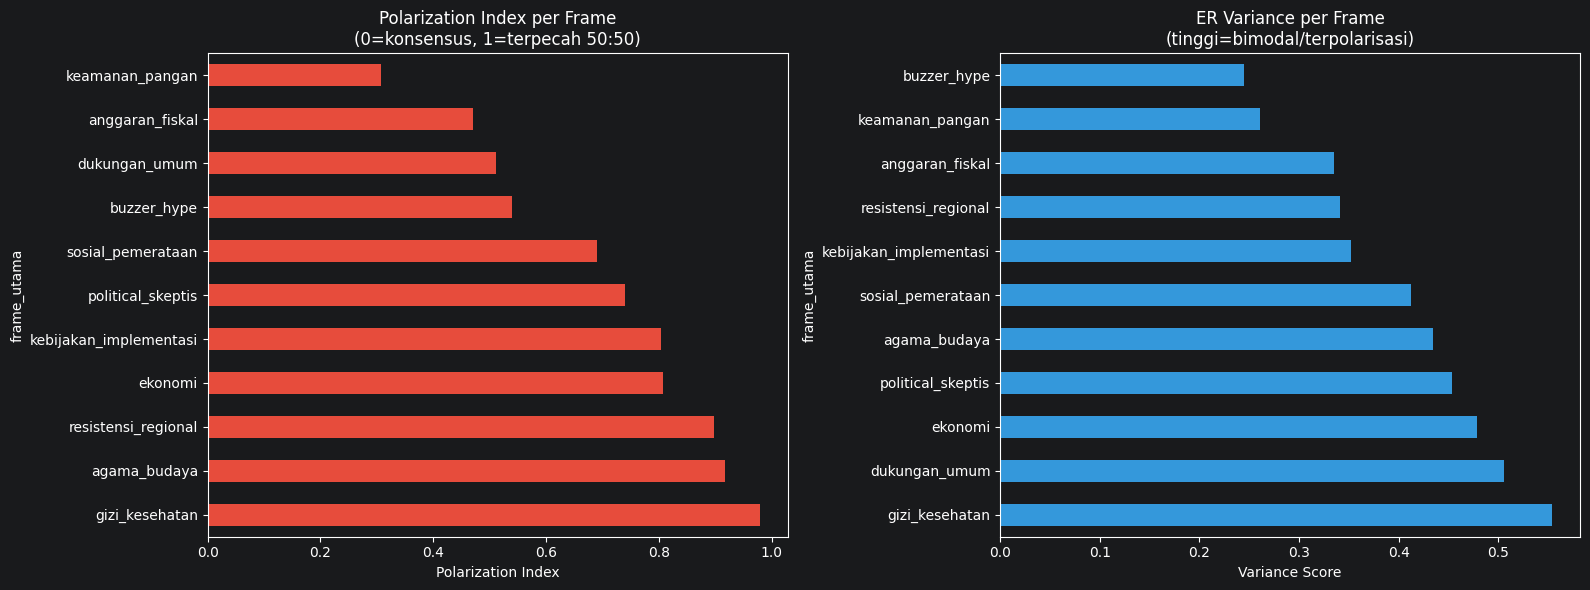

In [4]:
def polarization_index(group):
    """0 = semua satu suara, 1 = tepat 50:50 pos vs neg"""
    pos = (group == 'positif').mean()
    neg = (group == 'negatif').mean()
    return 1 - abs(pos - neg)

def esteban_ray_index(scores_pos, scores_neg):
    """Esteban-Ray inspired: mengukur bimodalitas distribusi skor"""
    combined = scores_pos - scores_neg  # range [-1, 1]
    if len(combined) < 10:
        return 0
    # Variance-based: tinggi = terpolarisasi
    return combined.var()

if 'frame_utama' in df.columns and 'sentiment_bert' in df.columns:
    # Simple polarization index
    frame_pol = df.groupby('frame_utama')['sentiment_bert'].apply(
        polarization_index
    ).sort_values(ascending=False)
    frame_pol = frame_pol.drop('tidak_terklasifikasi', errors='ignore')

    print("=== FRAME POLARIZATION INDEX (Simple) ===")
    print(frame_pol)

    # ER-inspired index
    if 'score_positif' in df.columns:
        frame_er = df.groupby('frame_utama').apply(
            lambda g: esteban_ray_index(g['score_positif'], g['score_negatif'])
        ).sort_values(ascending=False)
        frame_er = frame_er.drop('tidak_terklasifikasi', errors='ignore')
        print("\n=== FRAME POLARIZATION INDEX (Esteban-Ray Variance) ===")
        print(frame_er.round(4))

    # Visualisasi
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    frame_pol.plot(kind='barh', ax=axes[0], color='#e74c3c')
    axes[0].set_title('Polarization Index per Frame\n(0=konsensus, 1=terpecah 50:50)')
    axes[0].set_xlabel('Polarization Index')

    if 'score_positif' in df.columns:
        frame_er.plot(kind='barh', ax=axes[1], color='#3498db')
        axes[1].set_title('ER Variance per Frame\n(tinggi=bimodal/terpolarisasi)')
        axes[1].set_xlabel('Variance Score')

    plt.tight_layout()
    plt.savefig(f'{fig_pol_dir}/frame_polarization.png', dpi=150)
    plt.show()

## P6-03: Network-Based Polarization (Cross-Community Isolation)

Memetakan Interaksi Antar Komunitas: 100%|██████████| 13995/13995 [00:00<00:00, 1391439.92it/s]



=== NETWORK POLARIZATION ===
Total edges: 13995
Intra-community edges: 11803 (84.3%)
Inter-community edges: 2192 (15.7%)

Isolation Index: 0.8434


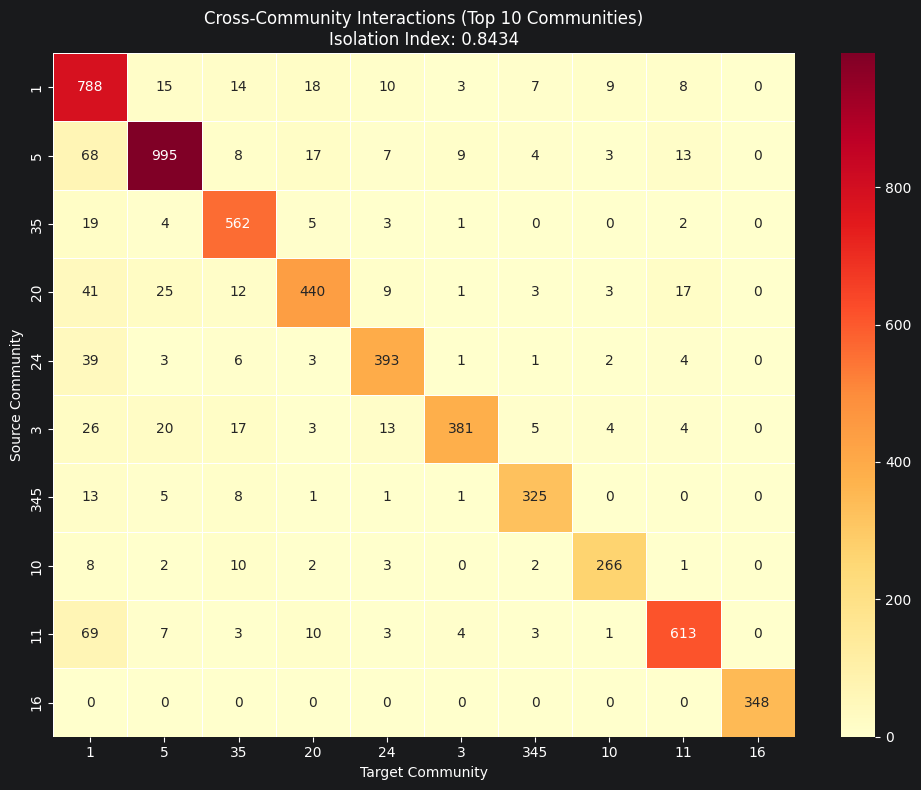


Pairwise Isolation (Komunitas 1 vs 5): 0.9555
  Komunitas 1: 629 users
  Komunitas 5: 600 users
  Cross-edges: 83


In [5]:
if G_combined is not None and partition is not None:
    from collections import Counter
    import numpy as np
    from tqdm import tqdm

    communities = set(partition.values())
    n_comm = len(communities)

    # 1. Ngitung interaksi secepat kilat pakai Numpy (kayak yang udah kita benerin)
    cross_matrix_np = np.zeros((n_comm, n_comm), dtype=int)
    for u, v in tqdm(G_combined.edges(), desc="Memetakan Interaksi Antar Komunitas"):
        cu = partition.get(u, -1)
        cv = partition.get(v, -1)
        if cu >= 0 and cv >= 0:
            cross_matrix_np[cu, cv] += 1

    cross_matrix = pd.DataFrame(cross_matrix_np, index=range(n_comm), columns=range(n_comm))

    total_edges = G_combined.number_of_edges()
    intra_edges = sum(cross_matrix.loc[c, c] for c in range(n_comm))
    inter_edges = total_edges - intra_edges

    isolation_index = 1 - (inter_edges / max(total_edges, 1))
    print(f"\n=== NETWORK POLARIZATION ===")
    print(f"Total edges: {total_edges}")
    print(f"Intra-community edges: {intra_edges} ({intra_edges/max(total_edges,1)*100:.1f}%)")
    print(f"Inter-community edges: {inter_edges} ({inter_edges/max(total_edges,1)*100:.1f}%)")
    print(f"\nIsolation Index: {isolation_index:.4f}")

    # ==========================================
    # VISUALISASI OPTIMIZED: Ambil Top 10 aja
    # ==========================================
    comm_sizes = Counter(partition.values())
    # Ambil 10 komunitas paling gede
    top_comms = [c for c, _ in comm_sizes.most_common(10)]

    # Filter cross_matrix cuma buat 10 komunitas itu
    top_matrix = cross_matrix.loc[top_comms, top_comms]

    plt.figure(figsize=(10, 8))
    # annot=True sekarang aman karena kotaknya cuma 10x10 = 100 kotak
    sns.heatmap(top_matrix, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
    plt.title(f'Cross-Community Interactions (Top 10 Communities)\nIsolation Index: {isolation_index:.4f}')
    plt.xlabel('Target Community')
    plt.ylabel('Source Community')
    plt.tight_layout()
    # Pastikan fig_pol_dir udah di-define ya
    plt.savefig(f'{fig_pol_dir}/cross_community_matrix.png', dpi=150)
    plt.show()

    # ==========================================
    # PAIRWISE ISOLATION TOP 2
    # ==========================================
    if len(top_comms) >= 2:
        c_a, c_b = top_comms[0], top_comms[1]
        nodes_a_count = comm_sizes[c_a]
        nodes_b_count = comm_sizes[c_b]

        cross_ab = cross_matrix.loc[c_a, c_b] + cross_matrix.loc[c_b, c_a]
        total_ab = cross_matrix.loc[c_a, c_a] + cross_matrix.loc[c_b, c_b] + cross_ab
        pairwise_isolation = 1 - (cross_ab / max(total_ab, 1))

        print(f"\nPairwise Isolation (Komunitas {c_a} vs {c_b}): {pairwise_isolation:.4f}")
        print(f"  Komunitas {c_a}: {nodes_a_count} users")
        print(f"  Komunitas {c_b}: {nodes_b_count} users")
        print(f"  Cross-edges: {cross_ab}")

else:
    print("Graph data not available. Run Fase 5 first.")

## P6-04: Temporal Polarization Trends

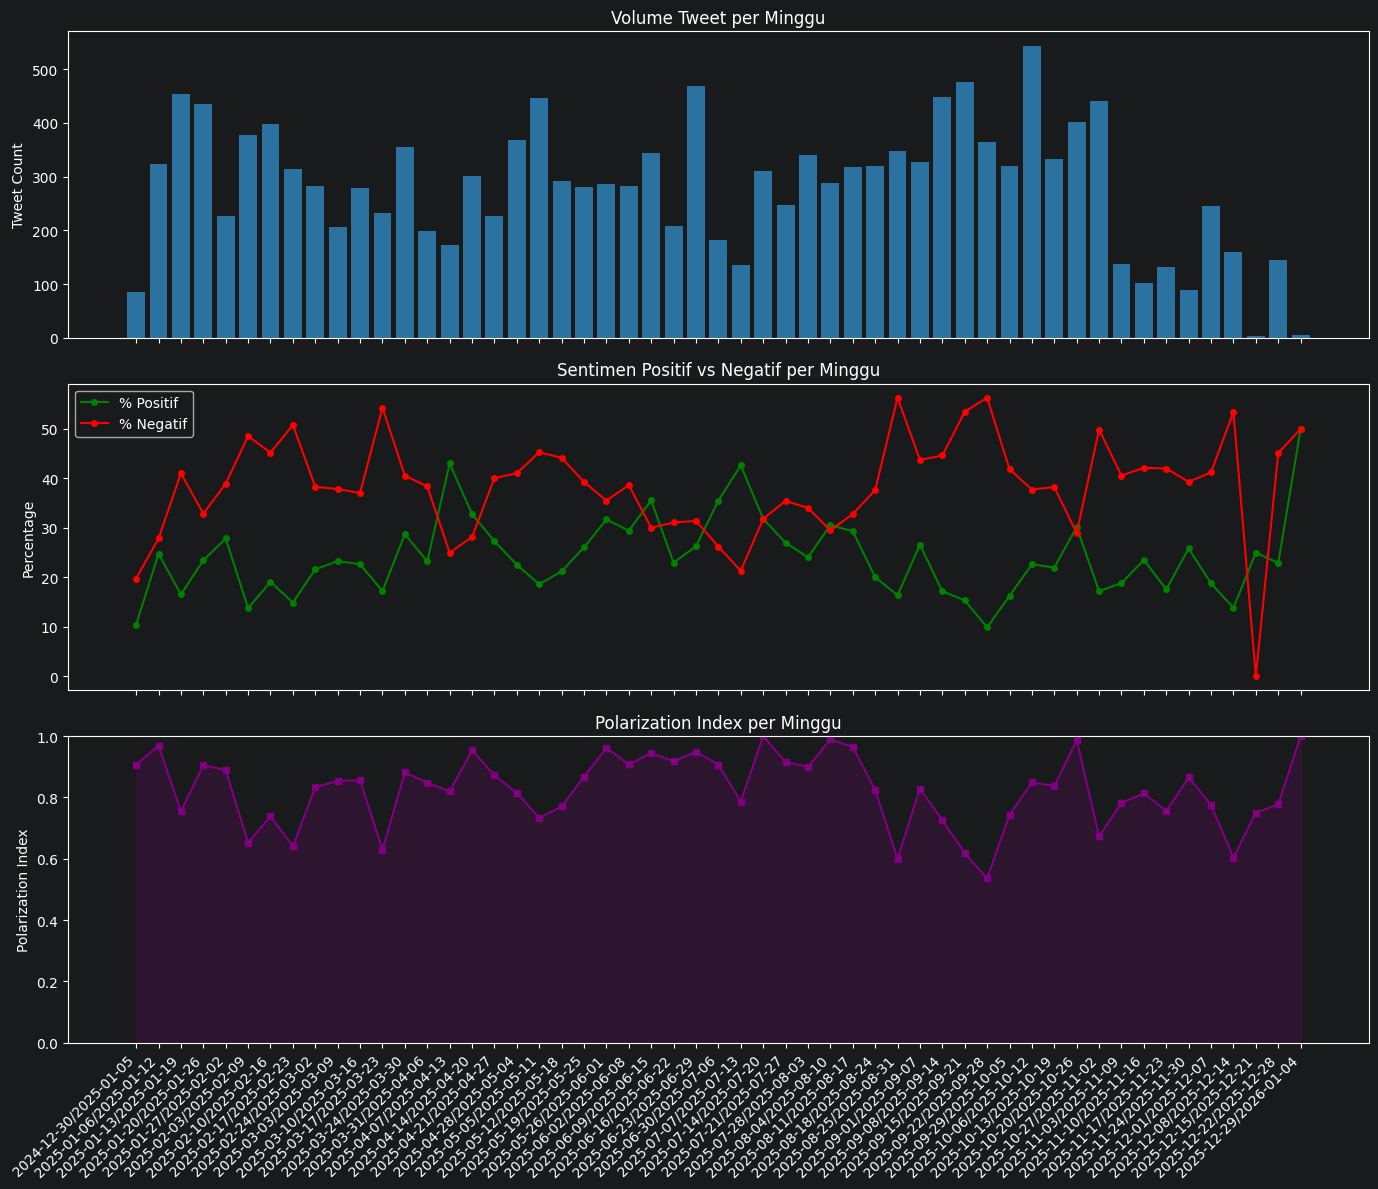

In [9]:
if 'created_at_dt' in df.columns and 'score_positif' in df.columns:
    df['week'] = df['created_at_dt'].dt.tz_localize(None).dt.to_period('W')

    weekly_pol = df.groupby('week').apply(
        lambda g: pd.Series({
            'polarization': polarization_index(g['sentiment_bert']),
            'avg_controversy': g['controversy_score'].mean() if 'controversy_score' in g.columns else 0,
            'tweet_count': len(g),
            'pct_negatif': (g['sentiment_bert'] == 'negatif').mean() * 100,
            'pct_positif': (g['sentiment_bert'] == 'positif').mean() * 100
        })
    ).reset_index()

    weekly_pol['week_str'] = weekly_pol['week'].astype(str)

    fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

    # Panel 1: Volume
    axes[0].bar(weekly_pol['week_str'], weekly_pol['tweet_count'], color='#3498db', alpha=0.7)
    axes[0].set_ylabel('Tweet Count')
    axes[0].set_title('Volume Tweet per Minggu')

    # Panel 2: Sentiment %
    axes[1].plot(weekly_pol['week_str'], weekly_pol['pct_positif'], 'g-o', label='% Positif', markersize=4)
    axes[1].plot(weekly_pol['week_str'], weekly_pol['pct_negatif'], 'r-o', label='% Negatif', markersize=4)
    axes[1].set_ylabel('Percentage')
    axes[1].set_title('Sentimen Positif vs Negatif per Minggu')
    axes[1].legend()

    # Panel 3: Polarization
    axes[2].plot(weekly_pol['week_str'], weekly_pol['polarization'], 'purple', marker='s', markersize=4)
    axes[2].fill_between(range(len(weekly_pol)), weekly_pol['polarization'], alpha=0.2, color='purple')
    axes[2].set_ylabel('Polarization Index')
    axes[2].set_title('Polarization Index per Minggu')
    axes[2].set_ylim(0, 1)

    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f'{fig_pol_dir}/temporal_polarization.png', dpi=150)
    plt.show()
else:
    print("Kolom created_at_dt atau score_positif belum ada.")

## P6-05: Korelasi Polarization × Topic × Community

In [7]:
# Polarization per topic (jika bert_topic ada)
if 'bert_topic' in df.columns and 'controversy_score' in df.columns:
    topic_pol = df[df['bert_topic'] != -1].groupby('bert_topic').agg(
        count=('tweet_id', 'count'),
        avg_controversy=('controversy_score', 'mean'),
        polarization=('sentiment_bert', polarization_index),
        pct_negatif=('sentiment_bert', lambda x: (x == 'negatif').mean() * 100),
        total_views=('view_count', 'sum')
    ).sort_values('polarization', ascending=False)

    if 'bert_topic_name' in df.columns:
        topic_names = df.groupby('bert_topic')['bert_topic_name'].first()
        topic_pol = topic_pol.join(topic_names)

    print("=== POLARIZATION PER TOPIC ===")
    print(topic_pol.round(3))

    # Scatter: polarization vs views (bubble = count)
    plt.figure(figsize=(12, 7))
    scatter = plt.scatter(
        topic_pol['polarization'], topic_pol['total_views'],
        s=topic_pol['count'] * 2, alpha=0.6,
        c=topic_pol['pct_negatif'], cmap='RdYlGn_r',
        edgecolors='black', linewidth=0.5
    )
    plt.colorbar(scatter, label='% Negatif')
    for idx, row in topic_pol.iterrows():
        name = row.get('bert_topic_name', str(idx))
        if isinstance(name, str):
            name = name[:25]
        plt.annotate(f'T{idx}', (row['polarization'], row['total_views']), fontsize=7)
    plt.xlabel('Polarization Index')
    plt.ylabel('Total Views')
    plt.title('Topik: Polarization vs Reach')
    plt.tight_layout()
    plt.savefig(f'{fig_pol_dir}/topic_polarization_reach.png', dpi=150)
    plt.show()

# Sentimen per komunitas (jika community ada)
if 'community' in df.columns:
    comm_sent = df.groupby('community')['sentiment_bert'].value_counts(normalize=True).mul(100).unstack(fill_value=0).round(1)
    print("\n=== SENTIMEN PER KOMUNITAS ===")
    print(comm_sent)


=== SENTIMEN PER KOMUNITAS ===
sentiment_bert  negatif  netral  positif
community                               
0.0                47.7    36.6     15.7
1.0                48.0    36.5     15.6
2.0                55.5    31.2     13.3
3.0                36.2    40.6     23.2
4.0               100.0     0.0      0.0
...                 ...     ...      ...
1513.0              0.0   100.0      0.0
1514.0              0.0    50.0     50.0
1515.0              0.0     0.0    100.0
1516.0            100.0     0.0      0.0
1517.0            100.0     0.0      0.0

[1518 rows x 3 columns]


## P6-06: Summary & Save

In [11]:
# Save controversy_score ke df
if 'controversy_score' in df.columns:
    df.to_csv(ANALYZED_DATA, index=False)
    print(f"Saved to {ANALYZED_DATA}")
    print(f"   Kolom baru: controversy_score")

if 'controversy_score' in df.columns:
    print(f"Mean controversy: {df['controversy_score'].mean():.3f}")
    print(f"Highly controversial tweets (>0.8): {(df['controversy_score'] > 0.8).sum()}")
if G_combined is not None:
    print(f"Network Isolation Index: {isolation_index:.4f}")
if 'frame_utama' in df.columns:
    print(f"Most polarized frame: {frame_pol.idxmax()} ({frame_pol.max():.3f})")
    print(f"Least polarized frame: {frame_pol.idxmin()} ({frame_pol.min():.3f})")

Saved to /Volumes/Livia's Storage/Users/Documents/Telkom_University/Outside_Classes/Competition/SatriaData/2026/internalTus/Data/Analyzed/mbg_analyzed.csv
   Kolom baru: controversy_score
Mean controversy: 0.389
Highly controversial tweets (>0.8): 5174
Network Isolation Index: 0.8434
Most polarized frame: gizi_kesehatan (0.979)
Least polarized frame: keamanan_pangan (0.308)
